#Datos de alumno
Estudiante: Octavio Quintero Flores

Matricula: 266226

Maestría en Inteligencia Artificial y Analítica de Datos

#Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


In [8]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target

In [3]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [4]:
feature_names = wine.feature_names
mag_index = feature_names.index('magnesium')
magnesium = X[:, mag_index]

In [6]:
from scipy.stats import shapiro
stat_orig, p_orig = shapiro(magnesium)
print("Original (Magnesium):")
print(f"Estadístico={stat_orig:.4f}, p-valor={p_orig:.4f}")

Original (Magnesium):
Estadístico=0.9383, p-valor=0.0000


In [9]:
#Normalizaremos con minmax, por lo cual lo agregamos a las librerias iniciales, donde tomaremos los valores (-1 a 1)
scaler = MinMaxScaler()
mag_scaled = scaler.fit_transform(magnesium.reshape(-1, 1)).flatten()

In [10]:
stat_scaled, p_scaled = shapiro(mag_scaled)

print("\nNormalizado (Magnesium):")
print(f"Estadístico={stat_scaled:.4f}, p-valor={p_scaled:.4f}")

#Haremos print para observar si existio cambios en los valores estadisticos


Normalizado (Magnesium):
Estadístico=0.9383, p-valor=0.0000


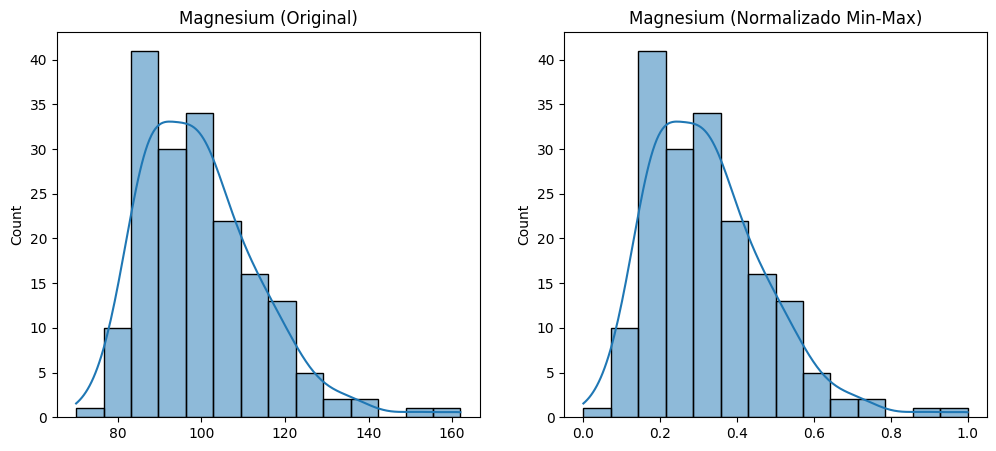

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(magnesium, kde=True)
plt.title("Magnesium (Original)")

plt.subplot(1,2,2)
sns.histplot(mag_scaled, kde=True)
plt.title("Magnesium (Normalizado Min-Max)")

plt.show()

#Respuestas pregunta 1
Podemos observar que en el Magnesium original tenemos un rango de valores hasta el 160, al normalizar cambiamos el rango hasta 1, no afectamos la forma de la grafica ni el valor p. Solamente normalizmos

* Ambas gráficas tienen la misma silueta
* Pico principal alrededor del centro
* Cola más larga hacia la derecha = sesgo positivo

La normalización Min-Max no cambió la forma, solo la “encogió” al rango [0,1]

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



In [12]:
# Seleccionar característica: total_phenols
phenols_index = feature_names.index('total_phenols')
phenols = X[:, phenols_index]



In [19]:
#Prueba de normalidad
stat_orig, p_orig = shapiro(phenols)
print("Original (total_phenols):")
print(f"Estadístico={stat_orig:.4f}, p-valor={p_orig:.4f}")

Original (total_phenols):
Estadístico=0.9767, p-valor=0.0044


In [20]:
#Normalizamos con standardscaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
phenols_scaled = scaler.fit_transform(phenols.reshape(-1, 1)).flatten()

In [21]:
#Prueba de normalidad en valores escalados
stat_scaled, p_scaled = shapiro(phenols_scaled)

print("\nNormalizado Z-Score:")
print(f"Estadístico={stat_scaled:.4f}, p-valor={p_scaled:.4f}")


Normalizado Z-Score:
Estadístico=0.9767, p-valor=0.0044


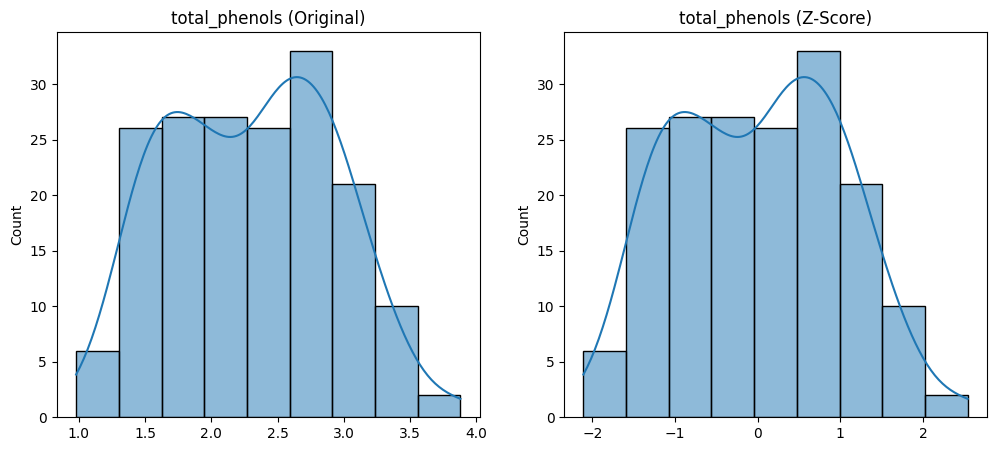

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(phenols, kde=True)
plt.title("total_phenols (Original)")

plt.subplot(1,2,2)
sns.histplot(phenols_scaled, kde=True)
plt.title("total_phenols (Z-Score)")

plt.show()

#Respuestas pregunta 2
La forma es prácticamente idéntica
Cambios:

* media = 0
* escala - desviación estándar = 1

Igual que Min-Max:

* No elimina skewness
* No vuelve normal la distribución
* Solo cambia escala y centro

El gráfico parece el mismo, solo “recentrado”

Zscore haace comparables variables con diferentes escalas
* Mejora algoritmos sensibles a distancia
* Centra los datos lo que es útil para modelos lineales

#Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


In [24]:
import numpy as np
np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)


In [26]:
#Generacion de datos
np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)

In [27]:
# Transformación logarítmica
log_data = np.log(data)

In [28]:
# Prueba de normalidad
stat_orig, p_orig = shapiro(data)
stat_log, p_log = shapiro(log_data)

print("Original:")
print(f"Estadístico={stat_orig:.4f}, p-valor={p_orig:.4f}")

print("\nLog-transformado:")
print(f"Estadístico={stat_log:.4f}, p-valor={p_log:.4f}")

Original:
Estadístico=0.8246, p-valor=0.0000

Log-transformado:
Estadístico=0.9567, p-valor=0.0000


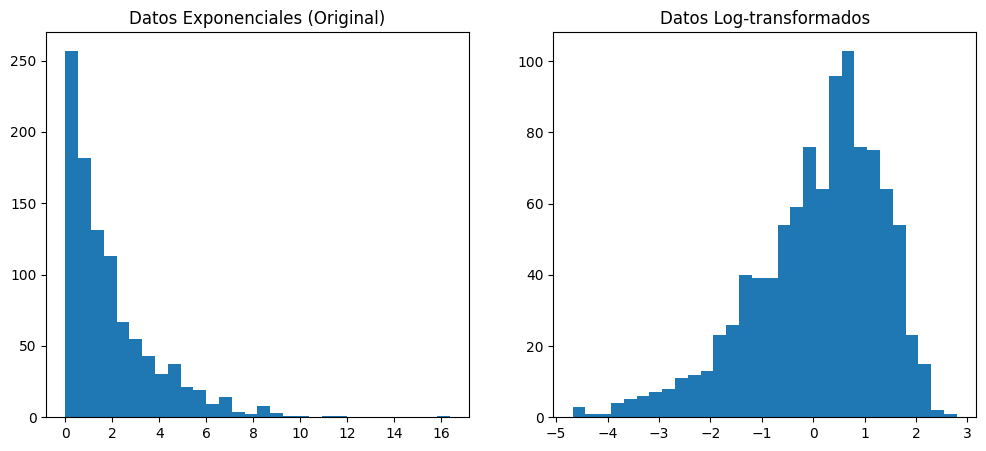

In [29]:
# Gráficas
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data, bins=30)
plt.title("Datos Exponenciales (Original)")

plt.subplot(1,2,2)
plt.hist(log_data, bins=30)
plt.title("Datos Log-transformados")

plt.show()

#Respuestas pregunta 3
Antes (izquierda):
Pico fuerte cerca de 0
Cola larga hacia la derecha
Sesgo positivo extremo

Esto es una exponencia desbalanceada y “estirada”.

Después (derecha):
Mucho más simétrica
Forma tipo campana
Cola mucho más controlada

El log realizo lo siguiente:

comprimió los valores grandes
“acercó” la distribución a una normal

En cuanto a los valores estadisticos y p valor

El estadístico subió de 0.82 → 0.95

El p valor siguio siendo 0 esto ya que shapiro sigue detectando imperfecciones y este 0 esta fuera de lo normal

#Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


In [30]:
# Generar datos
np.random.seed(42)
data = np.random.poisson(lam=5, size=1000)


In [31]:
# Transformación raíz cuadrada
sqrt_data = np.sqrt(data)

In [32]:
# Transformación raíz cuadrada
sqrt_data = np.sqrt(data)

In [34]:
#Prueba de normalidad
stat_orig, p_orig = shapiro(data)
stat_sqrt, p_sqrt = shapiro(sqrt_data)

print("Original (Poisson):")
print(f"Estadístico={stat_orig:.4f}, p-valor={p_orig:.4f}")

print("\nRaíz cuadrada:")
print(f"Estadístico={stat_sqrt:.4f}, p-valor={p_sqrt:.4f}")

Original (Poisson):
Estadístico=0.9722, p-valor=0.0000

Raíz cuadrada:
Estadístico=0.9682, p-valor=0.0000


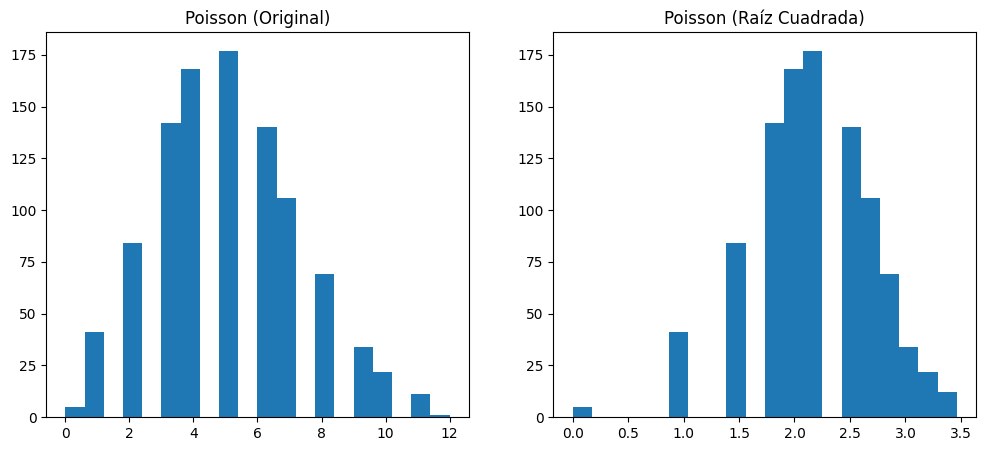

In [35]:
# Gráficas
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data, bins=20)
plt.title("Poisson (Original)")

plt.subplot(1,2,2)
plt.hist(sqrt_data, bins=20)
plt.title("Poisson (Raíz Cuadrada)")

plt.show()

#Respuestas pregunta 4
Podemos observar que afecto en que la grafica se puede observar como un suavizado de la grafica, tambien pasamos [0,12] a [0,3.5]

No hay un cambio dramático como con log, pero sí un suavizado

En cuanto a que paso con los valores extremos:

* Valores grandes se comprimen
* Valores pequeños casi no cambian

Por lo cual la cola derecha se ve menos extendida y los valores altos ya no dominan tanto


#Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


In [36]:
from scipy.stats import shapiro, boxcox

In [37]:
# Generar datos (log-normal)
np.random.seed(42)
data = np.random.lognormal(mean=1, sigma=0.8, size=1000)

In [39]:
# Transformación Box-Cox
data_boxcox, lambda_opt = boxcox(data)
print(f"Lambda óptimo: {lambda_opt:.4f}")


Lambda óptimo: -0.0489


In [40]:
# Pruebas de normalidad
stat_orig, p_orig = shapiro(data)
stat_bc, p_bc = shapiro(data_boxcox)

print("\nOriginal:")
print(f"Estadístico={stat_orig:.4f}, p-valor={p_orig:.4f}")

print("\nBox-Cox:")
print(f"Estadístico={stat_bc:.4f}, p-valor={p_bc:.4f}")



Original:
Estadístico=0.6538, p-valor=0.0000

Box-Cox:
Estadístico=0.9994, p-valor=0.9891


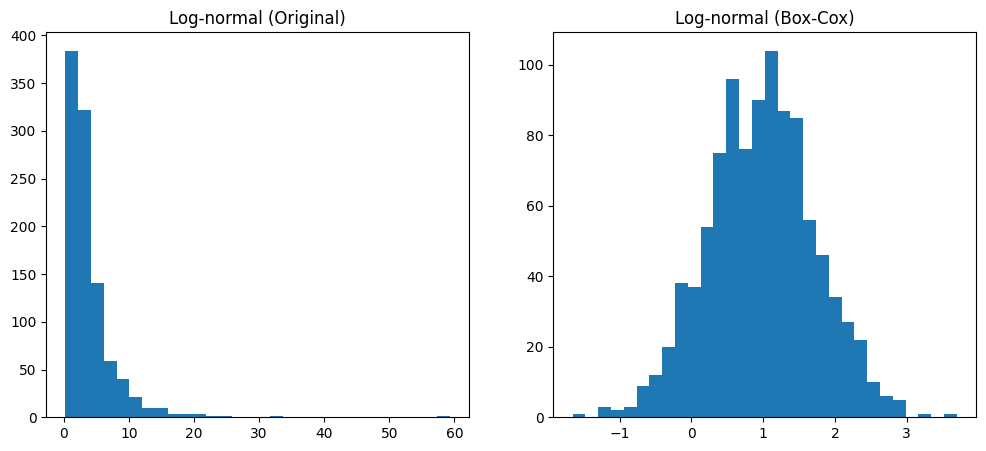

In [41]:
# Gráficas
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data, bins=30)
plt.title("Log-normal (Original)")

plt.subplot(1,2,2)
plt.hist(data_boxcox, bins=30)
plt.title("Log-normal (Box-Cox)")

plt.show()

#Respuestas pregunta 5
Antes (log-normal)
* Pico muy cargado hacia valores bajos
* Cola larga a la derecha
* Sesgo positivo fuerte

Una distribución no normal.

Después (Box-Cox)

* Forma tipo campana
* Más simétrica
* Cola controlada

El cambio es drástico

Ahora con el valor de lambda cercano a 0 nos indica que la transformacion optima es parecida a una transformacion logaritmica.